# Paper-Aligned PCA Analysis\n\nReplicates *Determining Conversational Styles at Scale* with paper-aligned column choices: **Table 1's 14 features minus the 3 pitch features = 11 features**. Where the paper specifies a per-second rate (Filler Word Rate, Pronoun Rate), we use our `*per Second` columns rather than the proportions.

In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import seaborn as sns
import matplotlib.pyplot as plt

## Step 1 — Load

In [2]:
df = pd.read_csv("../utterances_v2/merge_test.csv")
print(f"Shape: {df.shape}")

Shape: (214204, 39)


## Step 2 — Paper-Aligned Feature Columns (Table 1 minus pitch)\n\n| Paper Table 1 | Our column |\n|---|---|\n| Token Count (Linguistic) | `token_count` |\n| Mean Loudness (Audio) | `loudness mean` |\n| Loudness StdDev (Audio) | `loudness std` |\n| Loudness Range (Audio) | `loudness range` |\n| Turn Gap (Timing) | `Turn Gap` |\n| Word Rate (Timing) | `word_rate` |\n| Syllable Rate (Timing) | `syllable_rate` |\n| Pronoun Rate – per second (Timing) | `Pronouns per Second` |\n| Self-repetitions (Timing) | `Repetitions In Current Utterance` |\n| Prev-repetitions (Timing) | `Repetitions In Previous Utterance` |\n| Filler Word Rate – per second (Timing) | `Filler Words per Second` |

In [3]:
feature_cols = [
    "token_count",
    "loudness mean",
    "loudness std",
    "loudness range",
    "Turn Gap",
    "word_rate",
    "syllable_rate",
    "Pronouns per Second",
    "Repetitions In Current Utterance",
    "Repetitions In Previous Utterance",
    "Filler Words per Second",
]
print(f"Feature columns ({len(feature_cols)}):")
for c in feature_cols:
    print(f"  {c}")

Feature columns (11):
  token_count
  loudness mean
  loudness std
  loudness range
  Turn Gap
  word_rate
  syllable_rate
  Pronouns per Second
  Repetitions In Current Utterance
  Repetitions In Previous Utterance
  Filler Words per Second


## Step 3 — Clean

In [4]:
before = len(df)
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=feature_cols).reset_index(drop=True)
print(f"Rows before: {before}, after: {len(df)}, dropped: {before - len(df)}")

Rows before: 214204, after: 212210, dropped: 1994


## Step 4 — Normalize & PCA

In [5]:
X = df[feature_cols].values
X_norm = normalize(X)

n_components = len(feature_cols)
pca = PCA(n_components=n_components)
pca_result = pca.fit_transform(X_norm)

pca_cols = [f"pca{i}" for i in range(n_components)]
for i, col in enumerate(pca_cols):
    df[col] = pca_result[:, i]

print(f"PCA components: {n_components}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Cumulative variance: {np.cumsum(pca.explained_variance_ratio_)}")

PCA components: 11
Explained variance ratio: [5.78327446e-01 1.81202844e-01 1.08857342e-01 7.58167101e-02
 3.02871670e-02 1.15101840e-02 8.11688981e-03 5.67112758e-03
 2.08612896e-04 1.41875840e-06 2.57679327e-07]
Cumulative variance: [0.57832745 0.75953029 0.86838763 0.94420434 0.97449151 0.98600169
 0.99411858 0.99978971 0.99999832 0.99999974 1.        ]


## Step 5 — Histogram of PC0 & Explained Variance

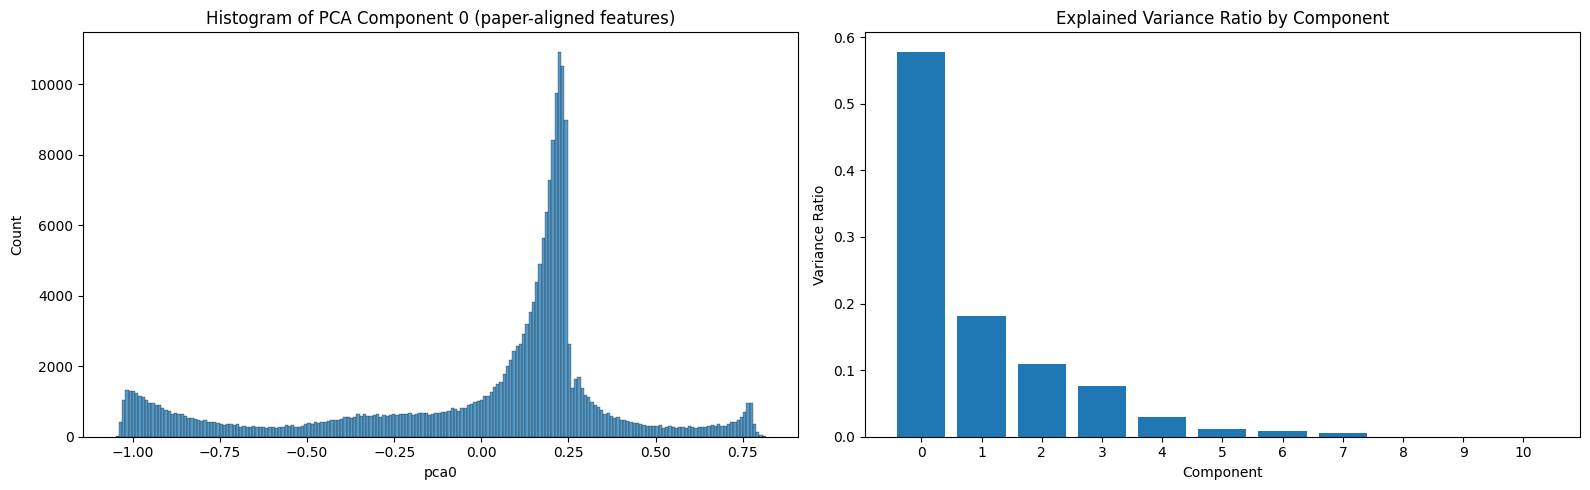

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df["pca0"], bins=200, ax=axes[0])
axes[0].set_title("Histogram of PCA Component 0 (paper-aligned features)")
axes[0].set_xlabel("pca0")

axes[1].bar(range(n_components), pca.explained_variance_ratio_)
axes[1].set_title("Explained Variance Ratio by Component")
axes[1].set_xlabel("Component")
axes[1].set_ylabel("Variance Ratio")
axes[1].set_xticks(range(n_components))

plt.tight_layout()
plt.show()

## Step 6 — Table 2: Feature Importance to PC0\n\nLoadings of each feature on PC0, sorted by absolute magnitude. PCA sign is arbitrary so the overall sign may flip relative to the paper.

In [7]:
loadings = pd.DataFrame({
    "Feature": feature_cols,
    "Magnitude": pca.components_[0],
})
loadings = (
    loadings.assign(_abs=loadings["Magnitude"].abs())
    .sort_values("_abs", ascending=False)
    .drop(columns="_abs")
    .reset_index(drop=True)
)
loadings["Magnitude"] = loadings["Magnitude"].apply(lambda x: f"{x:+.4f}")
loadings = loadings[["Magnitude", "Feature"]]
print("Table 2: Feature importance to Principal Component (PC0)\n")
print(loadings.to_string(index=False))

Table 2: Feature importance to Principal Component (PC0)

Magnitude                           Feature
  +0.9050                          Turn Gap
  +0.4066                       token_count
  +0.1055  Repetitions In Current Utterance
  +0.0528 Repetitions In Previous Utterance
  -0.0287                     syllable_rate
  -0.0258                         word_rate
  +0.0172               Pronouns per Second
  -0.0022                    loudness range
  +0.0010           Filler Words per Second
  -0.0007                      loudness std
  -0.0004                     loudness mean


## Step 7 — Silhouette Analysis (k = 2..10)

In [8]:
X1 = df["pca0"].values.reshape(-1, 1)
ks = list(range(2, 11))
sil_scores = []
for k in ks:
    gmm_k = GaussianMixture(n_components=k, random_state=0).fit(X1)
    labels = gmm_k.predict(X1)
    score = silhouette_score(X1, labels, sample_size=10000, random_state=0)
    sil_scores.append(score)
    print(f"k={k}: silhouette = {score:.4f}")

best_k = ks[int(np.argmax(sil_scores))]
print(f"\nBest k by silhouette: {best_k}")

k=2: silhouette = 0.7441


k=3: silhouette = 0.6865


k=4: silhouette = 0.6247


k=5: silhouette = 0.6246


k=6: silhouette = 0.5864


k=7: silhouette = 0.5587


k=8: silhouette = 0.5995


k=9: silhouette = 0.5903


k=10: silhouette = 0.5596

Best k by silhouette: 2


## Step 8 — BIC across k = 1..10\n\nBIC (Bayesian Information Criterion) is a model-selection score: **lower = better**. It rewards fit (likelihood) and penalizes complexity (each extra Gaussian costs `~3 · log(n)` ≈ 36 in BIC). Unlike silhouette, BIC **can pick k=1** — so if no clustering existed, k=1 would win. We compare to the silhouette result above.

In [9]:
print(f"{'k':>3} {'BIC':>14} {'Δ from k-1':>14}")
print("-" * 36)
bics = []
prev = None
for k in range(1, 11):
    gmm_k = GaussianMixture(n_components=k, random_state=0).fit(X1)
    bic = gmm_k.bic(X1)
    bics.append(bic)
    delta = "" if prev is None else f"{bic - prev:+.0f}"
    print(f"{k:>3} {bic:>14.0f} {delta:>14}")
    prev = bic

best_k_bic = int(np.argmin(bics)) + 1
print(f"\nBest k by BIC: {best_k_bic}")
print(f"Best k by silhouette: {best_k}")

  k            BIC     Δ from k-1
------------------------------------
  1         235649               
  2         129580        -106069


  3         108722         -20858


  4          25335         -83387


  5          22967          -2368


  6          16371          -6596


  7          11006          -5365


  8           6571          -4436


  9           4144          -2426


 10           1491          -2654

Best k by BIC: 10
Best k by silhouette: 2


## Step 9 — Best-k GMM fit & overlay

GMM with k=2 components:
  component 1: mean=-0.7005, std=0.2686, weight=0.213
  component 0: mean=+0.1895, std=0.1939, weight=0.787


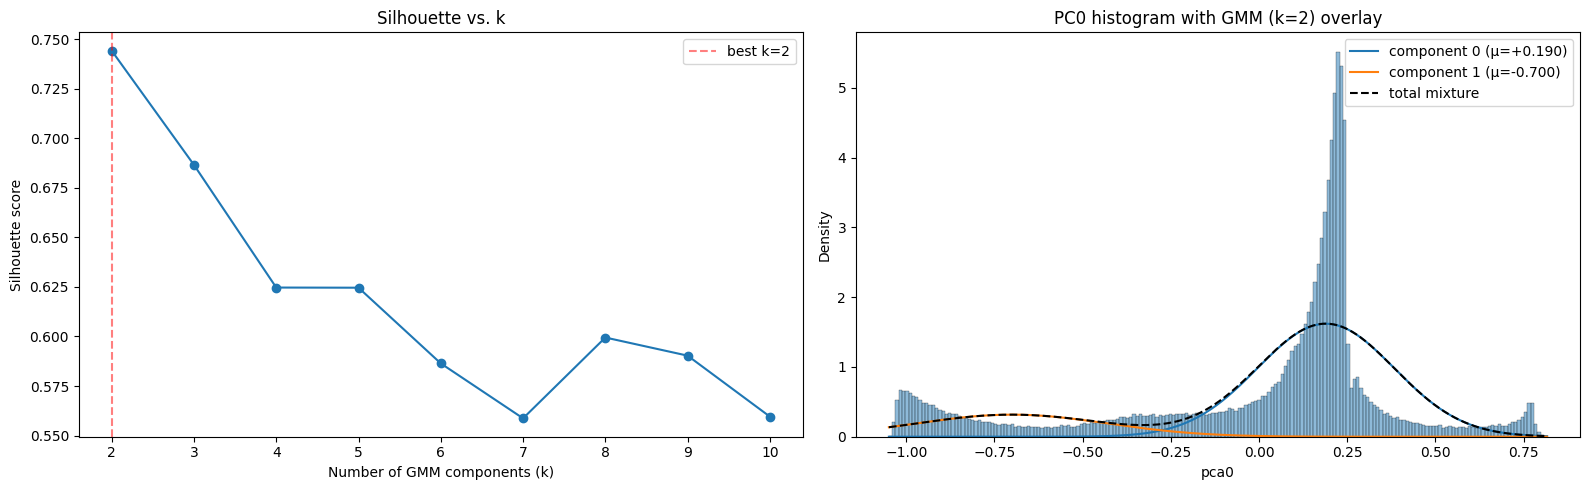


Hard label counts: {0: 167759, 1: 44451}


In [10]:
best_gmm = GaussianMixture(n_components=best_k, random_state=0).fit(X1)
means = best_gmm.means_.flatten()
stds = np.sqrt(best_gmm.covariances_.flatten())
weights = best_gmm.weights_
order = np.argsort(means)
print(f"GMM with k={best_k} components:")
for i in order:
    print(f"  component {i}: mean={means[i]:+.4f}, std={stds[i]:.4f}, weight={weights[i]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(ks, sil_scores, "o-")
axes[0].axvline(best_k, color="red", linestyle="--", alpha=0.5, label=f"best k={best_k}")
axes[0].set_xlabel("Number of GMM components (k)")
axes[0].set_ylabel("Silhouette score")
axes[0].set_title("Silhouette vs. k")
axes[0].legend()

sns.histplot(df["pca0"], bins=200, stat="density", ax=axes[1], alpha=0.5)
xs = np.linspace(X1.min(), X1.max(), 1000)
total = np.zeros_like(xs)
for i in range(best_k):
    component = (
        weights[i]
        * (1 / (stds[i] * np.sqrt(2 * np.pi)))
        * np.exp(-0.5 * ((xs - means[i]) / stds[i]) ** 2)
    )
    axes[1].plot(xs, component, label=f"component {i} (μ={means[i]:+.3f})")
    total += component
axes[1].plot(xs, total, "k--", label="total mixture")
axes[1].set_xlabel("pca0")
axes[1].set_title(f"PC0 histogram with GMM (k={best_k}) overlay")
axes[1].legend()

plt.tight_layout()
plt.show()

df["gmm_label"] = best_gmm.predict(X1)
print(f"\nHard label counts: {df['gmm_label'].value_counts().to_dict()}")

## Step 10 — Export

In [11]:
output_path = "../utterances_v2/paper_aligned_PCA_552026.csv"
df.to_csv(output_path, index=False)
print(f"Saved {len(df)} rows x {len(df.columns)} columns to {output_path}")

Saved 212210 rows x 51 columns to ../utterances_v2/paper_aligned_PCA_552026.csv
